# S7 · Tree Ensembles: Random Forests, Gradient Boosting and When They Help

*Signal Research track*

Random forests and gradient boosting are the workhorses of applied machine learning on tabular data. This notebook explains how they work, applies them where there *is* something to predict, and compares them honestly with a simple linear model.

## 1. Motivation

S6 ended on a sobering note: a gradient-boosting model found nothing in next month's stock returns. Does that mean machine learning is useless in finance? No. It means returns are extremely hard to predict, by anything. Other financial quantities are much more predictable. **Volatility** is the best example (notebook 2: risk comes in waves). Forecasting it well is directly useful for the Portfolio & Risk team: position sizing (P5), VaR (P6) and risk parity (P3) all need a volatility forecast. So: can tree ensembles forecast next month's volatility better than simple methods?

## 2. Intuition

**A decision tree** predicts by asking a sequence of yes/no questions: "Is recent volatility above 30%? If yes, is the VIX above 25?..." Each leaf at the end of the questions holds a prediction, the average target of the training examples that landed there. Trees capture non-linear effects and interactions automatically, but a single deep tree memorises its training data (it overfits).

Two ways to fix that by combining many trees:

- **Random forest (bagging):** grow hundreds of deep trees, each on a random resample of the data and considering a random subset of features at each split. Then average them. Individual trees are noisy, but their errors partly cancel. Think of asking many independent experts and averaging their answers.
- **Gradient boosting:** grow many *small* trees one after another. Each new tree is trained to predict the errors the ensemble is still making. Think of a student who studies exactly the questions they got wrong last time.

Neither one guarantees better forecasts than a straight line. If the true relationship is roughly linear, the extra flexibility mostly fits noise. Always compare against simple baselines.

## 3. The math

**Target.** For stock $i$ at month-end $t$, the log of realised volatility over the next 21 trading days:
$$
y_{i,t} = \ln\!\Big(\sqrt{252}\;\operatorname{std}\big(r_{i,t+1},\dots,r_{i,t+21}\big)\Big).
$$
We use logs because volatility is skewed and always positive. In logs, errors are roughly symmetric, and a model can't predict a negative volatility.

**Features** (all known at $t$): log realised volatility over the past 5, 21, 63 and 252 days, the past month's return, the VIX, market volatility, and a volume shock.

**Models.**
- *Naive:* $\hat y_{i,t} = $ log volatility over the last 21 days ("next month looks like last month").
- *Linear:* $\hat y = a + \sum_k b_k x_k$, fitted by least squares. With the volatility features, this is close to the well-known **HAR model** (heterogeneous autoregressive), a standard benchmark for volatility forecasting.
- *Random forest:* $\hat y = \frac{1}{B}\sum_{b=1}^{B} T_b(x)$, the average of $B$ trees grown on resampled data.
- *Gradient boosting:* $\hat y = \sum_{m=1}^{M} \nu\, T_m(x)$, where each small tree $T_m$ is fitted to the residuals of the previous ones, and $\nu$ (the **learning rate**) shrinks each step.

**Evaluation.** Walk-forward by year (S6). We report the mean squared error (MSE) and the out-of-sample $R^2$ relative to the naive forecast: $R^2_{\text{oos}} = 1 - \text{MSE}_{\text{model}} / \text{MSE}_{\text{naive}}$. A positive value means the model beats "same as last month".

**Which features matter?** **Permutation importance**: shuffle one feature in the test data and measure how much the error increases. If shuffling a feature barely matters, the model wasn't using it.

## 4. Code it

### 4.1 Setup: features and target

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)
volume = pd.read_csv("../data/volume.csv", index_col="date", parse_dates=True)
meta = pd.read_csv("../data/meta.csv")

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})
pd.set_option("display.width", 120)

stocks = meta.loc[meta.asset_type == "stock", "ticker"]
px, vol = prices[stocks], volume[stocks]
r = np.log(px).diff()

def log_vol(window):
    return np.log(r.rolling(window).std() * np.sqrt(252))

def broadcast(series):
    """Repeat a market-wide series (e.g. the VIX) for every stock."""
    return pd.DataFrame({t: series for t in stocks})

features = {
    "vol_5d": log_vol(5), "vol_21d": log_vol(21), "vol_63d": log_vol(63), "vol_252d": log_vol(252),
    "ret_21d": px / px.shift(21) - 1,
    "vix": broadcast(np.log(prices["^VIX"])),
    "mkt_vol_21d": broadcast(np.log(prices["SPY"].pct_change().rolling(21).std() * np.sqrt(252))),
    "volume_shock": np.log((px * vol).rolling(5).mean() / (px * vol).rolling(63).mean()),
}
h = 21
# Volatility over days t+1 ... t+21: reverse time, take a rolling window, reverse back, shift by one
future_vol = r[::-1].rolling(h).std()[::-1].shift(-1) * np.sqrt(252)
target = np.log(future_vol)

panel = pd.concat({k: f.stack() for k, f in features.items()}, axis=1)
panel["y"] = target.stack()
panel = panel.dropna()
panel = panel[panel.index.get_level_values("date") >= "2011-01-01"]
dates = panel.index.get_level_values("date")
month_end = np.asarray(dates.isin(px.groupby(px.index.to_period("M")).tail(1).index))
X, y = panel.drop(columns="y"), panel["y"]
print(f"{len(panel):,} stock-days; {month_end.sum():,} month-end test points")

169,334 stock-days; 8,084 month-end test points


### 4.2 Walk-forward comparison of four forecasts

Each year, every model is trained on all data whose target window ended before the year started. It then forecasts each stock's volatility at every month-end of that year.

In [2]:
models = {
    "Linear (HAR-style)": lambda: LinearRegression(),
    "Random forest": lambda: RandomForestRegressor(n_estimators=200, min_samples_leaf=50, max_features=0.5,
                                                   max_samples=0.2, n_jobs=-1, random_state=0),
    "Gradient boosting": lambda: HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
                                                              min_samples_leaf=200, random_state=0),
}
mse = {name: {} for name in ["Naive (last month)"] + list(models)}
fitted = {}
for year in range(2015, dates[-1].year + 1):
    test = np.asarray(dates.year == year) & month_end
    train = np.asarray(dates < pd.Timestamp(f"{year}-01-01") - pd.Timedelta(days=35))  # label ends before the year
    y_test = y[test]
    mse["Naive (last month)"][year] = ((y_test - X.loc[test, "vol_21d"]) ** 2).mean()
    for name, make in models.items():
        m = make().fit(X[train], y[train])
        mse[name][year] = ((y_test - m.predict(X[test])) ** 2).mean()
        fitted[name] = (m, test)      # keep the latest year's model for the importance analysis

mse = pd.DataFrame(mse)
summary = pd.DataFrame({"MSE (log vol)": mse.mean(),
                        "R² vs naive": 1 - mse.mean() / mse["Naive (last month)"].mean(),
                        "Years beating linear": (mse.lt(mse["Linear (HAR-style)"], axis=0)).sum()})
summary.round(3)

,MSE (log vol),R² vs naive,Years beating linear
Naive (last month),0.181,0.000,0
Linear (HAR-style),0.126,0.300,0
Random forest,0.129,0.284,4
Gradient boosting,0.134,0.257,3


- **All three models beat the naive forecast by a lot.** They cut the forecast error by 26–30%. Volatility really is predictable, and combining several look-back windows works much better than looking at last month alone.
- **The plain linear model is the best on average** (R² ≈ 0.30 vs naive). The random forest is very close (0.28) and beats it in 4 of 12 years. Gradient boosting comes third.

This is a common finding in volatility forecasting. The relationship between past and future log volatility is close to linear, and the HAR-style linear model is a famously hard benchmark to beat. The tree ensembles' extra flexibility didn't find much that the linear model missed.

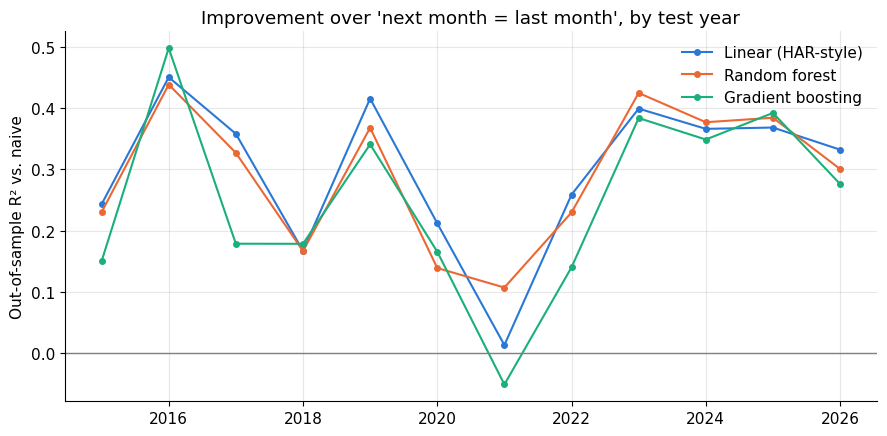

In [3]:
fig, ax = plt.subplots()
for name, c in [("Linear (HAR-style)", COLORS[0]), ("Random forest", COLORS[1]), ("Gradient boosting", COLORS[2])]:
    ax.plot(mse.index, 1 - mse[name] / mse["Naive (last month)"], marker="o", markersize=4, label=name, color=c)
ax.axhline(0, color="grey", linewidth=1)
ax.set_ylabel("Out-of-sample R² vs. naive")
ax.set_title("Improvement over 'next month = last month', by test year")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Every model improves on the naive forecast in almost every year. The models also move together: years that are hard for one are hard for all. The weakest year is 2021. After the 2020 crash, the long look-back windows (63 and 252 days) still remembered extreme volatility, so all models predicted more turbulence than the calmer 2021 delivered. Gradient boosting even fell slightly behind the naive forecast that year. The random forest coped best, which is typical of averaged ensembles: they are rarely the best, but also rarely the worst.

### 4.3 What did the models learn?

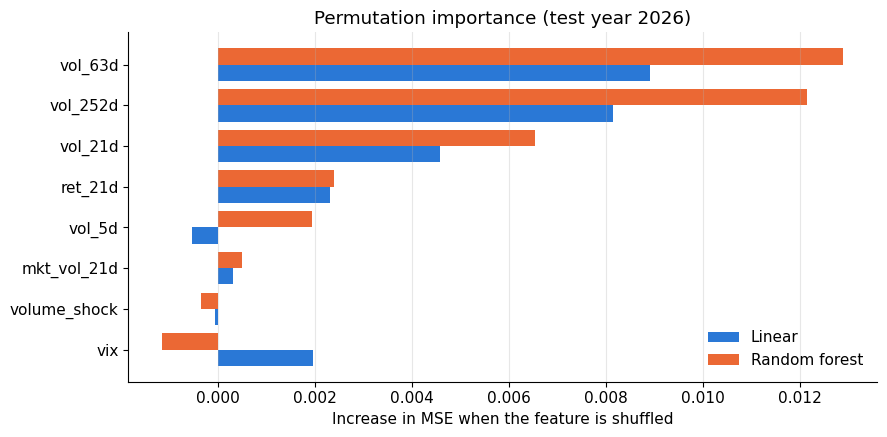

In [4]:
imp = {}
for name in ["Linear (HAR-style)", "Random forest"]:
    m, test = fitted[name]
    pi = permutation_importance(m, X[test], y[test], n_repeats=10, random_state=0,
                                scoring="neg_mean_squared_error")
    imp[name] = pd.Series(pi.importances_mean, index=X.columns)    # increase in MSE when shuffled
imp = pd.DataFrame(imp).sort_values("Random forest")

fig, ax = plt.subplots(figsize=(9, 4.5))
yy = np.arange(len(imp))
ax.barh(yy - 0.2, imp["Linear (HAR-style)"], height=0.4, color=COLORS[0], label="Linear")
ax.barh(yy + 0.2, imp["Random forest"], height=0.4, color=COLORS[1], label="Random forest")
ax.set_yticks(yy, imp.index)
ax.set_xlabel("Increase in MSE when the feature is shuffled")
ax.set_title(f"Permutation importance (test year {dates[-1].year})")
ax.legend(frameon=False)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

Both models rely mainly on the same features: medium- and long-term volatility (63 and 252 days), then the last month's volatility. Volatility tends to revert towards each stock's long-run level, so the long windows carry a lot of information. The past month's return matters too: stocks that just fell tend to become more volatile (the "leverage effect").

The two models disagree on a few smaller features, such as the VIX. That doesn't mean one of them is wrong. The VIX, market volatility and the stock volatility windows are correlated, so a model can get similar information from several of them. Permutation importance then spreads the credit unpredictably, and can even show slightly negative values when shuffling a redundant feature happens to help by chance.

## 5. Takeaways and where it breaks

- **Trees capture non-linearities and interactions automatically.** Random forests average many deep trees; boosting adds small trees that fix the remaining errors.
- **Use ML where there is signal.** Volatility is highly predictable, and every model beat the naive forecast by a wide margin. Returns are not (S6).
- **Always benchmark against a simple model.** Here a linear model was as good as or better than the tree ensembles. Flexibility helps only if the data contains structure that a linear model misses.
- **Where it breaks:** tree ensembles can't extrapolate beyond the range of the training data, so a never-seen-before VIX level gets the prediction of the highest one seen. And tuning their many settings on the test years is overfitting (notebook 6).
- **Interpret with care.** Permutation importance is unreliable when features are strongly correlated (the four volatility windows are), because the model can lean on whichever correlated feature remains.

**What you could build:** a volatility-forecasting service for the Portfolio & Risk team: monthly forecasts for every asset from a linear benchmark plus a tree model, with a running scoreboard of which one has been more accurate.